<a href="https://www.kaggle.com/code/sonukumarg25ait2110/mlops-project-group-38?scriptVersionId=330986705" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# MLOps Emotion Detection Pipeline — Group 38
**Dataset**: `dair-ai/emotion` &nbsp;|&nbsp; **Task**: 6-class Text Emotion Classification  
**Model**: `distilbert-base-uncased` fine-tuned for sequence classification  
**Tracking**: Weights & Biases &nbsp;|&nbsp; **Registry**: Hugging Face Hub

---

### Emotion Classes
| ID | Label    |
|----|----------|
| 0  | sadness  |
| 1  | joy      |
| 2  | love     |
| 3  | anger    |
| 4  | fear     |
| 5  | surprise |

> **Note**: `mlops-group-project.ipynb` in this repo is a reference notebook for pipeline structure only.  
> This notebook (`emotion-detection-kaggle.ipynb`) is the actual training notebook for **Group 38**.

## Step 0 — Load Secrets
**On Kaggle**: Add `WANDB_API_KEY`, `HF_TOKEN`, `HF_REPO_ID` in  
*Add-ons → Secrets* before running.

In [1]:
import os

# ── Kaggle Secrets ──────────────────────────────────────────────────────────
try:
    from kaggle_secrets import UserSecretsClient
    _secrets = UserSecretsClient()
    os.environ["WANDB_API_KEY"] = _secrets.get_secret("WANDB_API_KEY")
    os.environ["HF_TOKEN"]      = _secrets.get_secret("HF_TOKEN")
    os.environ["HF_REPO_ID"]    = _secrets.get_secret("HF_REPO_ID")
    print("Kaggle secrets loaded.")
except Exception:
    print("Not on Kaggle — reading secrets from environment variables.")

WANDB_API_KEY = os.environ.get("WANDB_API_KEY", "")
HF_TOKEN      = os.environ.get("HF_TOKEN", "")
HF_REPO_ID    = os.environ.get("HF_REPO_ID", "your-username/mlops-group38-emotion")

print(f"HF_REPO_ID : {HF_REPO_ID}")
print(f"WANDB key  : {'set' if WANDB_API_KEY else 'NOT SET'}")
print(f"HF token   : {'set' if HF_TOKEN else 'NOT SET'}")

Kaggle secrets loaded.
HF_REPO_ID : Sonu-kumar-IIT/distilbert-base
WANDB key  : set
HF token   : set


## Step 1 — Install Dependencies

In [2]:
# Uninstall incompatible peft (not needed for our fine-tuning)
# then install correct transformers version
!pip uninstall -y peft 2>/dev/null || true
!pip install -q --upgrade \
    "transformers==4.46.3" \
    "accelerate>=0.34.0" \
    datasets \
    wandb \
    scikit-learn \
    evaluate \
    seaborn \
    matplotlib \
    huggingface_hub
print("Install complete. Go to Session → Restart & Run All now.")

Found existing installation: peft 0.18.1
Uninstalling peft-0.18.1:
  Successfully uninstalled peft-0.18.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.8/26.8 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 101.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 111.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━

## Step 2 — Initialise W&B

In [3]:
import wandb

WANDB_PROJECT  = "emotion-mlops-group38-project"
WANDB_RUN_NAME = "run-v1"   # change to 'run-v2' for second experiment

if WANDB_API_KEY:
    wandb.login(key=WANDB_API_KEY, relogin=False)
    wandb.init(
        project=WANDB_PROJECT,
        name=WANDB_RUN_NAME,
        config={
            "model": "distilbert-base-uncased",
            "dataset": "dair-ai/emotion",
            "task": "emotion-detection",
            "num_labels": 6,
            "train_size": 16000,
            "val_size": 2000,
            "test_size": 2000,
            "max_seq_length": 128,
            "learning_rate": 2e-5,
            "epochs": 4,
            "batch_size": 32,
            "weight_decay": 0.01,
            "warmup_ratio": 0.06,
        },
        reinit="finish_previous",   # replaces deprecated reinit=True
    )
    print("W&B run started:", wandb.run.url)
else:
    print("W&B disabled — WANDB_API_KEY not set.")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: g25ait2110 (mlops-assignment2) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.28.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260628_084806-h3cosbnl
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run run-v1
wandb: ⭐️ View project at https://wandb.ai/mlops-assignment2/emotion-mlops-group38-project
wandb: 🚀 View run at https://wandb.ai/mlops-assignment2/emotion-mlops-group38-project/runs/h3cosbnl


W&B run started: https://wandb.ai/mlops-assignment2/emotion-mlops-group38-project/runs/h3cosbnl


## Step 3 — Configuration

In [4]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"   # suppress fork warning

# ── Hyperparameters ──────────────────────────────────────────────────────────
MODEL_NAME              = "distilbert-base-uncased"
DATASET_NAME            = "dair-ai/emotion"
MAX_SEQ_LENGTH          = 128
TRAIN_SIZE              = 16000
VAL_SIZE                = 2000
TEST_SIZE               = 2000
LEARNING_RATE           = 2e-5
NUM_TRAIN_EPOCHS        = 4
TRAIN_BATCH_SIZE        = 32
EVAL_BATCH_SIZE         = 64
WEIGHT_DECAY            = 0.01
WARMUP_RATIO            = 0.06
OUTPUT_DIR              = "/kaggle/working/checkpoints"

# ── Label mapping ────────────────────────────────────────────────────────────
ID2LABEL = {0: "sadness", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"}
LABEL2ID = {v: k for k, v in ID2LABEL.items()}
NUM_LABELS = len(ID2LABEL)

print(f"Model      : {MODEL_NAME}")
print(f"Dataset    : {DATASET_NAME}")
print(f"Num labels : {NUM_LABELS}  →  {list(ID2LABEL.values())}")

Model      : distilbert-base-uncased
Dataset    : dair-ai/emotion
Num labels : 6  →  ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


## Step 4 — Load & Explore Dataset

In [5]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

raw = load_dataset(DATASET_NAME)
print(raw)

# Show sample rows
df_sample = pd.DataFrame(raw["train"].select(range(10)))
df_sample["emotion"] = df_sample["label"].map(ID2LABEL)
display(df_sample)

README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger
5,ive been feeling a little burdened lately wasn...,0,sadness
6,ive been taking or milligrams or times recomme...,5,surprise
7,i feel as confused about life as a teenager or...,4,fear
8,i have been with petronas for years i feel tha...,1,joy
9,i feel romantic too,2,love



TRAIN (16000 samples):
  sadness   :  4666  (29.2%)
  joy       :  5362  (33.5%)
  love      :  1304  (8.2%)
  anger     :  2159  (13.5%)
  fear      :  1937  (12.1%)
  surprise  :   572  (3.6%)

VALIDATION (2000 samples):
  sadness   :   550  (27.5%)
  joy       :   704  (35.2%)
  love      :   178  (8.9%)
  anger     :   275  (13.8%)
  fear      :   212  (10.6%)
  surprise  :    81  (4.0%)

TEST (2000 samples):
  sadness   :   581  (29.0%)
  joy       :   695  (34.8%)
  love      :   159  (8.0%)
  anger     :   275  (13.8%)
  fear      :   224  (11.2%)
  surprise  :    66  (3.3%)


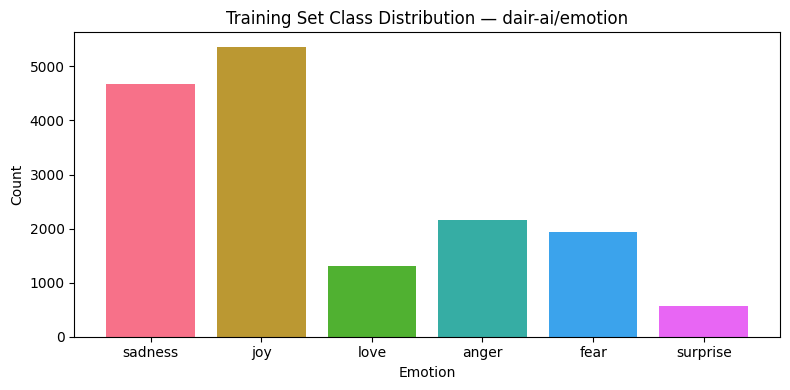

In [6]:
# ── Class distribution ───────────────────────────────────────────────────────
from collections import Counter

for split_name in ["train", "validation", "test"]:
    counts = Counter(raw[split_name]["label"])
    print(f"\n{split_name.upper()} ({len(raw[split_name])} samples):")
    for label_id, cnt in sorted(counts.items()):
        print(f"  {ID2LABEL[label_id]:10s}: {cnt:5d}  ({cnt/len(raw[split_name])*100:.1f}%)")

# Bar chart
train_counts = Counter(raw["train"]["label"])
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([ID2LABEL[i] for i in sorted(train_counts)],
       [train_counts[i] for i in sorted(train_counts)],
       color=sns.color_palette("husl", 6))
ax.set_title("Training Set Class Distribution — dair-ai/emotion")
ax.set_xlabel("Emotion")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## Step 5 — Data Cleaning & Tokenisation

In [7]:
import re

def clean_text(text: str) -> str:
    """Normalise raw text for emotion classification.

    Cleaning decisions:
      1. Lower-case — emotion signals are not case-dependent
      2. Remove URLs — carry no emotion signal
      3. Remove @mentions — not relevant to emotion content
      4. Strip # symbol but keep hashtag words
      5. Remove non-ASCII characters — keeps text clean for tokeniser
      6. Keep sentiment-bearing punctuation (. , ! ?)
      7. Collapse multiple whitespace
    """
    text = text.lower()
    text = re.sub(r"https?://\S+|www\.\S+", "", text)      # remove URLs
    text = re.sub(r"@\w+", "", text)                          # remove @mentions
    text = re.sub(r"#(\w+)", r"\1", text)                    # strip # symbol
    text = text.encode("ascii", errors="ignore").decode()     # remove non-ASCII
    text = re.sub(r"[^a-z0-9\s'.,!?]", " ", text)           # keep useful chars
    text = re.sub(r"\s+", " ", text).strip()                 # collapse spaces
    return text

# Quick sanity check
samples = [
    "I feel SO happy today!!! 😊 #blessed",
    "This is terrible @user https://example.com",
    "I'm afraid of what might happen...",
]
for s in samples:
    print(f"  IN : {s}")
    print(f"  OUT: {clean_text(s)}\n")

  IN : I feel SO happy today!!! 😊 #blessed
  OUT: i feel so happy today!!! blessed

  IN : This is terrible @user https://example.com
  OUT: this is terrible

  IN : I'm afraid of what might happen...
  OUT: i'm afraid of what might happen...



In [8]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=HF_TOKEN or None)

def preprocess(batch):
    cleaned = [clean_text(t) for t in batch["text"]]
    enc = tokenizer(cleaned, truncation=True, padding="max_length", max_length=MAX_SEQ_LENGTH)
    enc["labels"] = batch["label"]
    return enc

train_raw = raw["train"].select(range(min(TRAIN_SIZE, len(raw["train"]))))
val_raw   = raw["validation"].select(range(min(VAL_SIZE, len(raw["validation"]))))
test_raw  = raw["test"].select(range(min(TEST_SIZE, len(raw["test"]))))

# Apply cleaning + tokenisation
remove_cols = ["text", "label"]
train_ds = train_raw.map(preprocess, batched=True, remove_columns=remove_cols)
val_ds   = val_raw.map(preprocess,   batched=True, remove_columns=remove_cols)
test_ds  = test_raw.map(preprocess,  batched=True, remove_columns=remove_cols)

train_ds.set_format("torch")
val_ds.set_format("torch")
test_ds.set_format("torch")

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
print("Sample keys:", list(train_ds[0].keys()))

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Train: 16000 | Val: 2000 | Test: 2000
Sample keys: ['input_ids', 'attention_mask', 'labels']


## Step 6 — Load Model

In [9]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True,
    token=HF_TOKEN or None,
)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable:,}")

2026-06-28 08:48:32.415950: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782636512.579377      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782636512.630647      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782636513.005416      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782636513.005467      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782636513.005470      23 computation_placer.cc:177] computation placer alr

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters    : 66,958,086
Trainable parameters: 66,958,086


## Step 7 — Define Metrics

In [10]:
import numpy as np
from sklearn.metrics import classification_report

LABEL_NAMES = [ID2LABEL[i] for i in range(NUM_LABELS)]

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    report = classification_report(
        labels, preds,
        target_names=LABEL_NAMES,
        output_dict=True,
        zero_division=0,
    )
    return {
        "accuracy":        report["accuracy"],
        "f1":              report["weighted avg"]["f1-score"],
        "precision":       report["weighted avg"]["precision"],
        "recall":          report["weighted avg"]["recall"],
        "macro_f1":        report["macro avg"]["f1-score"],
        "macro_precision": report["macro avg"]["precision"],
        "macro_recall":    report["macro avg"]["recall"],
    }

print("compute_metrics function ready.")

compute_metrics function ready.


## Step 8 — Train

**Experiment V1** (default): `lr=2e-5`, `epochs=4`  
**Experiment V2**: change `LEARNING_RATE = 5e-5`, `NUM_TRAIN_EPOCHS = 6`, `WANDB_RUN_NAME = 'run-v2'`

In [11]:
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer)
report_to     = "wandb" if WANDB_API_KEY else "none"

training_args = TrainingArguments(
    output_dir              = OUTPUT_DIR,
    num_train_epochs        = NUM_TRAIN_EPOCHS,
    per_device_train_batch_size = TRAIN_BATCH_SIZE,
    per_device_eval_batch_size  = EVAL_BATCH_SIZE,
    learning_rate           = LEARNING_RATE,
    weight_decay            = WEIGHT_DECAY,
    warmup_ratio            = WARMUP_RATIO,
    eval_strategy           = "epoch",
    save_strategy           = "epoch",
    load_best_model_at_end  = True,
    metric_for_best_model   = "f1",
    logging_steps           = 100,
    fp16                    = True,   # GPU only
    report_to               = report_to,
    run_name                = WANDB_RUN_NAME,
    push_to_hub             = False,
)

trainer = Trainer(
    model             = model,
    args              = training_args,
    train_dataset     = train_ds,
    eval_dataset      = val_ds,
    processing_class  = tokenizer,   # replaces deprecated tokenizer= param
    data_collator     = data_collator,
    compute_metrics   = compute_metrics,
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Macro F1,Macro Precision,Macro Recall
1,0.659000,0.283496,0.912000,0.912119,0.913099,0.912000,0.877616,0.877741,0.879164
2,0.204300,0.167525,0.932500,0.932988,0.934035,0.932500,0.904111,0.896652,0.912761
3,0.128800,0.150583,0.934500,0.934979,0.935993,0.934500,0.906521,0.897413,0.917022
4,0.106800,0.151057,0.934000,0.933789,0.933916,0.934000,0.902592,0.905153,0.900554


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

TrainOutput(global_step=1000, training_loss=0.34690152645111083, metrics={'train_runtime': 411.2721, 'train_samples_per_second': 155.615, 'train_steps_per_second': 2.431, 'total_flos': 2119629570048000.0, 'train_loss': 0.34690152645111083, 'epoch': 4.0})

## Step 9 — Evaluate on Test Split

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


              precision    recall  f1-score   support

     sadness       0.97      0.96      0.96       581
         joy       0.96      0.94      0.95       695
        love       0.81      0.87      0.84       159
       anger       0.94      0.93      0.93       275
        fear       0.90      0.88      0.89       224
    surprise       0.71      0.83      0.76        66

    accuracy                           0.93      2000
   macro avg       0.88      0.90      0.89      2000
weighted avg       0.93      0.93      0.93      2000



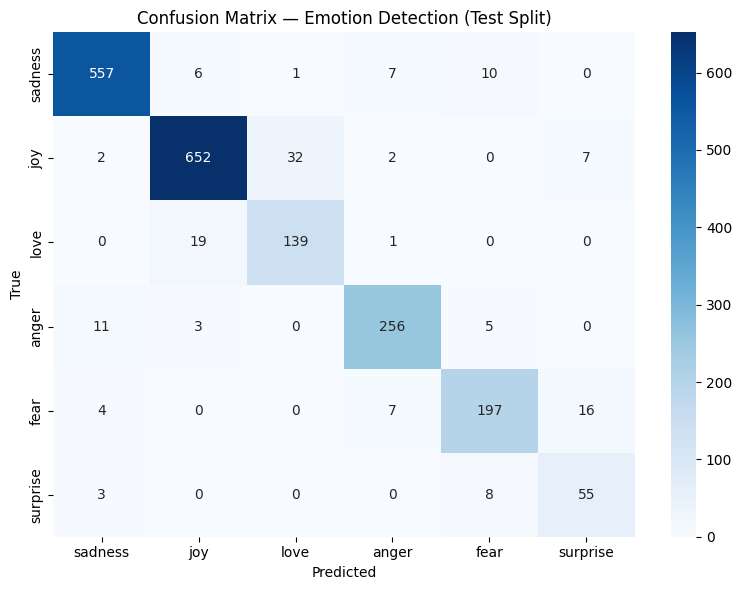

In [12]:
import json
import seaborn as sns
from sklearn.metrics import confusion_matrix

pred_output = trainer.predict(test_ds)
preds  = np.argmax(pred_output.predictions, axis=-1)
labels = pred_output.label_ids

# Classification report
report_txt  = classification_report(labels, preds, target_names=LABEL_NAMES, zero_division=0)
report_dict = classification_report(labels, preds, target_names=LABEL_NAMES,
                                    output_dict=True, zero_division=0)
print(report_txt)

# Save to files
import os
os.makedirs("/kaggle/working/eval_results", exist_ok=True)
with open("/kaggle/working/eval_results/classification_report.txt", "w") as f:
    f.write(report_txt)
with open("/kaggle/working/eval_results/classification_report.json", "w") as f:
    json.dump(report_dict, f, indent=2)

# Confusion matrix
cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            cmap="Blues", ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix — Emotion Detection (Test Split)")
plt.tight_layout()
plt.savefig("/kaggle/working/eval_results/confusion_matrix.png", dpi=150)
plt.show()

# Log to W&B
if wandb.run is not None:
    wandb.log({"confusion_matrix": wandb.Image("/kaggle/working/eval_results/confusion_matrix.png")})
    wandb.log({
        "final/accuracy":        report_dict["accuracy"],
        "final/weighted_f1":     report_dict["weighted avg"]["f1-score"],
        "final/macro_f1":        report_dict["macro avg"]["f1-score"],
        "final/macro_precision": report_dict["macro avg"]["precision"],
        "final/macro_recall":    report_dict["macro avg"]["recall"],
    })

## Step 10 — Push to Hugging Face Hub

In [13]:
if HF_TOKEN:
    print(f"Pushing model to Hub: {HF_REPO_ID}")
    model.push_to_hub(HF_REPO_ID, token=HF_TOKEN)
    tokenizer.push_to_hub(HF_REPO_ID, token=HF_TOKEN)
    hub_url = f"https://huggingface.co/{HF_REPO_ID}"
    print("Model URL:", hub_url)
    if wandb.run is not None:
        wandb.run.summary["huggingface_model"] = hub_url
else:
    print("HF_TOKEN not set — skipping Hub push.")

Pushing model to Hub: Sonu-kumar-IIT/distilbert-base


README.md:   0%|          | 0.00/21.0 [00:00<?, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


Model URL: https://huggingface.co/Sonu-kumar-IIT/distilbert-base


## Step 11 — Inference Demo

In [14]:
from transformers import pipeline as hf_pipeline

classifier = hf_pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    top_k=None,
    truncation=True,
    max_length=MAX_SEQ_LENGTH,
)

test_sentences = [
    "I am so happy today, everything feels perfect!",
    "I feel really sad and lonely right now.",
    "This makes me so angry, how could they do this?",
    "I am terrified of what will happen next.",
    "Wow, I did not expect that at all!",
    "I love spending time with my family.",
]

print(f"{'Text':<55} {'Predicted Emotion':<12} {'Confidence'}")
print("-" * 80)
for sentence in test_sentences:
    result = classifier(sentence)[0]
    best   = sorted(result, key=lambda x: x["score"], reverse=True)[0]
    print(f"{sentence[:54]:<55} {best['label']:<12} {best['score']:.4f}")

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


Text                                                    Predicted Emotion Confidence
--------------------------------------------------------------------------------
I am so happy today, everything feels perfect!          joy          0.9949
I feel really sad and lonely right now.                 sadness      0.9930
This makes me so angry, how could they do this?         anger        0.9898
I am terrified of what will happen next.                fear         0.9842
Wow, I did not expect that at all!                      joy          0.6625
I love spending time with my family.                    joy          0.5267


## Step 12 — Finish W&B Run

In [15]:
if wandb.run is not None:
    wandb.finish()
    print("W&B run finished.")
print("All done!")

wandb: updating run metadata
wandb: 
wandb: Run history:
wandb:           eval/accuracy ▁▇██
wandb:                 eval/f1 ▁▇██
wandb:               eval/loss █▂▁▁
wandb:           eval/macro_f1 ▁▇█▇
wandb:    eval/macro_precision ▁▆▆█
wandb:       eval/macro_recall ▁▇█▅
wandb:          eval/precision ▁▇█▇
wandb:             eval/recall ▁▇██
wandb:            eval/runtime █▂▁▁
wandb: eval/samples_per_second ▁▇██
wandb:                     +22 ...
wandb: 
wandb: Run summary:
wandb:           eval/accuracy 0.934
wandb:                 eval/f1 0.93379
wandb:               eval/loss 0.15106
wandb:           eval/macro_f1 0.90259
wandb:    eval/macro_precision 0.90515
wandb:       eval/macro_recall 0.90055
wandb:          eval/precision 0.93392
wandb:             eval/recall 0.934
wandb:            eval/runtime 4.125
wandb: eval/samples_per_second 484.845
wandb:                     +28 ...
wandb: 
wandb: 🚀 View run run-v1 at: https://wandb.ai/mlops-assignment2/emotion-mlops-group38-project

W&B run finished.
All done!
